In [2]:
# Import necessary libraries
import tensorflow as tf

# Let me load the CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Check the shapes of the data
print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)


In [3]:
# CIFAR-10 has 10 classes
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Label names:", label_names)

Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


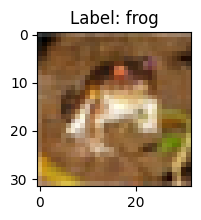

In [4]:
# Plot the image - 0th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[0])
plt.title(f"Label: {label_names[y_train[0][0]]}")
plt.show()

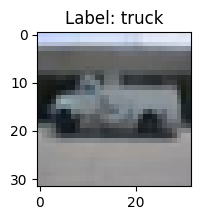

In [5]:
# Plot the image - 110th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.imshow(X_train[110])
plt.title(f"Label: {label_names[y_train[110][0]]}")
plt.show()

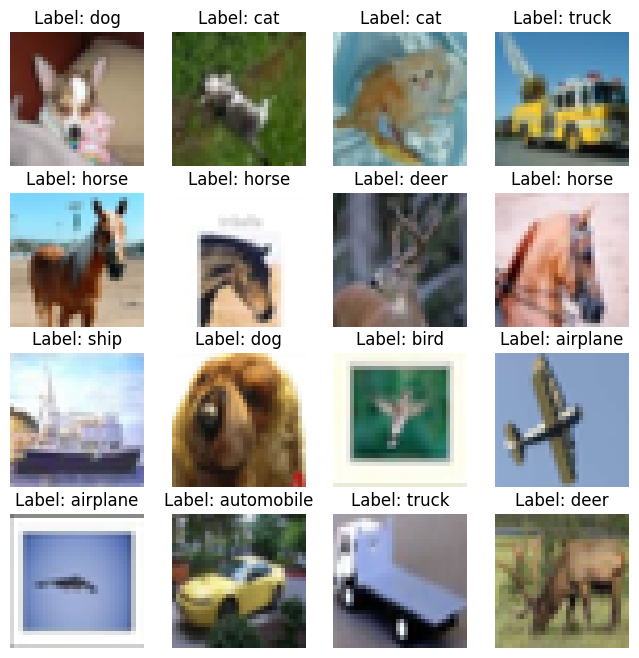

In [6]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx][0]]}")
    axes[row, col].axis("off")

plt.show()

In [7]:
y_train.shape

(50000, 1)

In [8]:
# Also note over here that the targets are 2D array N x 1 instead of N.
# Therefore, we flatten them.
y_train, y_test = y_train.flatten(), y_test.flatten()
print(y_train.shape)
print(y_test.shape)

(50000,)
(10000,)


In [9]:
# number of classes
K = len(set(y_train))
print("number of classes:", K)

number of classes: 10


In [10]:
# Now lets normalize the pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

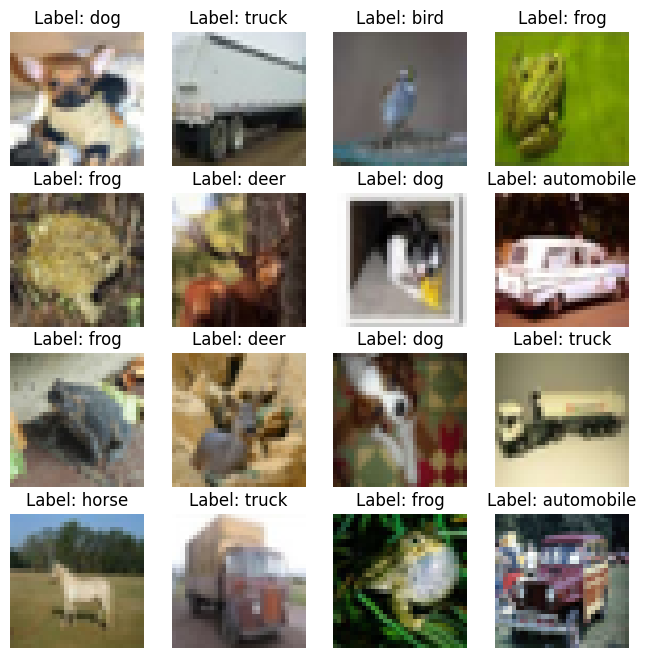

In [11]:
# Lets plot a grid of 4x4 images from the training set along with their labels in the title - randomly select 16 images from the training set
import random
import matplotlib.pyplot as plt

# Randomly select 16 images from the training set
selected_indices = random.sample(range(len(X_train)), 16)

# Create a grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
# Plot each selected image with its label
for i, idx in enumerate(selected_indices):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X_train[idx])
    axes[row, col].set_title(f"Label: {label_names[y_train[idx]]}")
    axes[row, col].axis("off")
plt.show()

In [12]:
# Now let's create a ANN model for image classification on CIFAR-10 dataset. We will look into the performance of ANN on this dataset and then confirm our hypothesis that ANN will not perform well on this dataset and then we will move on to CNNs which are more suitable for image data.

# from tensorflow.keras import Sequential
# from tensorflow.keras.layers import Flatten, Dense, Dropout, Input

# model = Sequential()
# model.add(Input(shape=(32, 32, 3)))
# model.add(Flatten())

# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(10, activation='softmax'))

In [13]:
# Now we are ready to build the model. We will use a simple CNN architecture with 3 convolutional layers followed by a fully connected layer and an output layer.

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(32, 32, 3)))

# model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
# model.add(MaxPooling2D((2, 2)))
# model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
# model.add(MaxPooling2D((2, 2)))
# 32x32 -> 16x16 -> 8x8 -> 4x4

# Lines 9-14 can also be written in a shorter way using strides parameter in Conv2D layer. 
# model.add(Conv2D(32, (3, 3), activation='relu', padding='same', strides=2))
# model.add(Conv2D(64, (3, 3), activation='relu', padding='same', strides=2))
# model.add(Conv2D(128, (3, 3), activation='relu', padding='same', strides=2))

# # Lets add batch normalization layer after each convolutional layer to improve the performance of the model.
# from tensorflow.keras.layers import BatchNormalization
# model.add(Conv2D(32, (3, 3), activation='relu', padding='same', strides=2))
# model.add(BatchNormalization())
# model.add(Conv2D(64, (3, 3), activation='relu', padding='same', strides=2))
# model.add(BatchNormalization())
# model.add(Conv2D(128, (3, 3), activation='relu', padding='same', strides=2))
# model.add(BatchNormalization())

# model.add(Flatten())
# model.add(Dense(256, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(10, activation='softmax'))

# additional imports

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
# Build the model using the functional API
i = Input(shape=(32, 32, 3))
# x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
# x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
# x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
# x = Dropout(0.2)(x)

# x = GlobalMaxPooling2D()(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [14]:
32*32*3

3072

In [15]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,397,226 (9.14 MB)

 Trainable params: 2,396,330 (9.14 MB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Train the model - 9min 20 secs
r = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=64)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 121ms/step - accuracy: 0.4549 - loss: 1.8080 - val_accuracy: 0.6527 - val_loss: 0.9828
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.6916 - loss: 0.8768 - val_accuracy: 0.7092 - val_loss: 0.8430
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 95s 122ms/step - accuracy: 0.7606 - loss: 0.6812 - val_accuracy: 0.7595 - val_loss: 0.6977
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 87s 112ms/step - accuracy: 0.8094 - loss: 0.5495 - val_accuracy: 0.7612 - val_loss: 0.7359
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 62s 79ms/step - accuracy: 0.8377 - loss: 0.4665 - val_accuracy: 0.7739 - val_loss: 0.6840
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 81ms/step - accuracy: 0.8626 - loss: 0.3957 - val_accuracy: 0.7952 - val_loss: 0.6340
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.8879 - loss: 0.3173 - val_accuracy: 0.8013 - val_loss: 0.6263
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.9074 - loss: 0.2611

In [ ]:
# Fit with data augmentation
# Note: if you run this AFTER calling the previous model.fit(), it will CONTINUE training where it left off
batch_size = 32
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10, # Randomly rotate images in the range (degrees, 0 to 180). 10 means rotate between -10 to +10 degrees
    width_shift_range=0.1, # Randomly shift images horizontally (fraction of total width). 0.1 means shift by 10% of the total width
    height_shift_range=0.1, # Randomly shift images vertically (fraction of total height). 0.1 means shift by 10% of the total height
    horizontal_flip=True, # Randomly flip images horizontally
    zoom_range=0.1 # Randomly zoom into images. 0.1 means zoom in by 10%
)
# This will create an iterator that will generate batches of augmented images and their corresponding labels on the fly during training
# The total number of  images generated will be equal to the number of batches per epoch (which is total number of training samples divided by batch size) multiplied by the number of epochs. So if we have 50000 training samples and batch size is 32, then we will have 1563 batches per epoch. If we train for 50 epochs, then we will have 1563 * 50 = 78150 augmented images generated during training.
train_generator = data_generator.flow(X_train, y_train, batch_size=batch_size)
steps_per_epoch = len(X_train) // batch_size
r = model.fit(train_generator, epochs=50, validation_data=(X_test, y_test), steps_per_epoch=steps_per_epoch)


Epoch 1/50


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.7610 - loss: 0.7852 - val_accuracy: 0.8167 - val_loss: 0.5788
Epoch 2/50
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 2:24 93ms/step - accuracy: 0.8438 - loss: 0.6687

/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8438 - loss: 0.6687 - val_accuracy: 0.8164 - val_loss: 0.5792
Epoch 3/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 133s 85ms/step - accuracy: 0.8257 - loss: 0.5226 - val_accuracy: 0.8424 - val_loss: 0.4949
Epoch 4/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8750 - loss: 0.4899 - val_accuracy: 0.8423 - val_loss: 0.4948
Epoch 5/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 126s 81ms/step - accuracy: 0.8440 - loss: 0.4695 - val_accuracy: 0.8431 - val_loss: 0.4927
Epoch 6/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8750 - loss: 0.2895 - val_accuracy: 0.8437 - val_loss: 0.4928
Epoch 7/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 121s 77ms/step - accuracy: 0.8527 - loss: 0.4350 - val_accuracy: 0.8382 - val_loss: 0.4976
Epoch 8/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8438 - loss: 0.4104 - val_accuracy: 0.8360 - val_loss: 0.5067
Epoch 9/50
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 111s 71ms/step - accuracy: 0.8623 - loss: 0.4078 -

In [ ]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='train accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_pred

In [ ]:
y_pred.shape

In [ ]:
y_test.shape

In [ ]:
# Lets look at the confusion matrix with True labels on x-axis and Predicted labels on y-axis
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Find the indices where predictions are incorrect
misclassified_indices = np.where(y_test.flatten() != y_pred)[0]
misclassified_indices

In [ ]:
# Print the total number of misclassified images
print(f'Total misclassified images: {len(misclassified_indices)}')

In [ ]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

In [ ]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

In [ ]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()

In [ ]:
# Lets randomly see 1 of the missclassified images along with their predicted and actual labels
import random
import matplotlib.pyplot as plt

# Randomly select one index from the misclassified indices
random_index = random.choice(misclassified_indices)

# Display the misclassified image along with its predicted and actual labels
plt.figure(figsize=(2, 2))
plt.imshow(X_test[random_index])
plt.title(f"Actual: {label_names[y_test[random_index]]}, Predicted: {label_names[y_pred[random_index]]}")
plt.axis("off")
plt.show()